# Customer Churn Prediction - Telco Dataset

**Business question:** Which customers are likely to cancel, and what drives it, so the retention team can act early?

**Workflow:** clean & validate -> EDA -> statistical tests -> feature engineering -> model comparison -> evaluation -> interpretation (SHAP) -> recommendations.

Reusable logic lives in `src/` so the notebook, the training script and the tests all use the same code.

In [1]:
import sys, warnings
sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

from src.config import RANDOM_STATE, TARGET, ID_COL, FIG_DIR
from src.data_prep import load_raw, clean, validate

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 40)
np.random.seed(RANDOM_STATE)

## 1. Load, clean and validate

In [2]:
raw = load_raw()
print("Raw shape:", raw.shape)
raw.head()

Raw shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Data-quality issues in the raw file
print("Duplicate rows:", raw.duplicated().sum())
print("Dtype of TotalCharges:", raw["TotalCharges"].dtype, "(should be numeric)")
blank = raw["TotalCharges"].str.strip() == ""
print("Blank TotalCharges:", blank.sum())
print("Their tenure values:", raw.loc[blank, "tenure"].unique())

Duplicate rows: 0
Dtype of TotalCharges: str (should be numeric)
Blank TotalCharges: 11
Their tenure values: [0]


**Finding:** 11 rows have a blank `TotalCharges`, and all of them have `tenure = 0`. These are brand-new customers who have not been billed yet, so the correct fill value is **0**, not the mean or median.

In [4]:
df = clean(raw)
checks = validate(df)
pd.Series(checks, name="passed").to_frame()

,passed
no_missing_values,True
unique_customer_ids,True
target_is_binary,True
tenure_non_negative,True
monthly_charges_positive,True
total_charges_non_negative,True
total_charges_numeric,True


## 2. Exploratory data analysis

Overall churn rate: 26.5%  (1869 of 7043 customers)


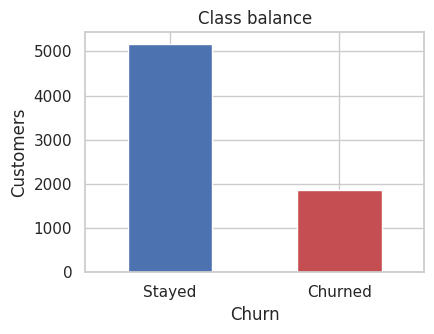

In [5]:
churn_rate = df[TARGET].mean()
print(f"Overall churn rate: {churn_rate:.1%}  ({df[TARGET].sum()} of {len(df)} customers)")

fig, ax = plt.subplots(figsize=(4.5, 3.5))
df[TARGET].map({0: "Stayed", 1: "Churned"}).value_counts().plot.bar(ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_title("Class balance"); ax.set_ylabel("Customers"); plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig(FIG_DIR / "class_balance.png", dpi=150); plt.show()

The data is imbalanced (about 27% churn), so accuracy alone would be misleading. I will focus on recall, precision, F1 and ROC-AUC, and use class weights during training.

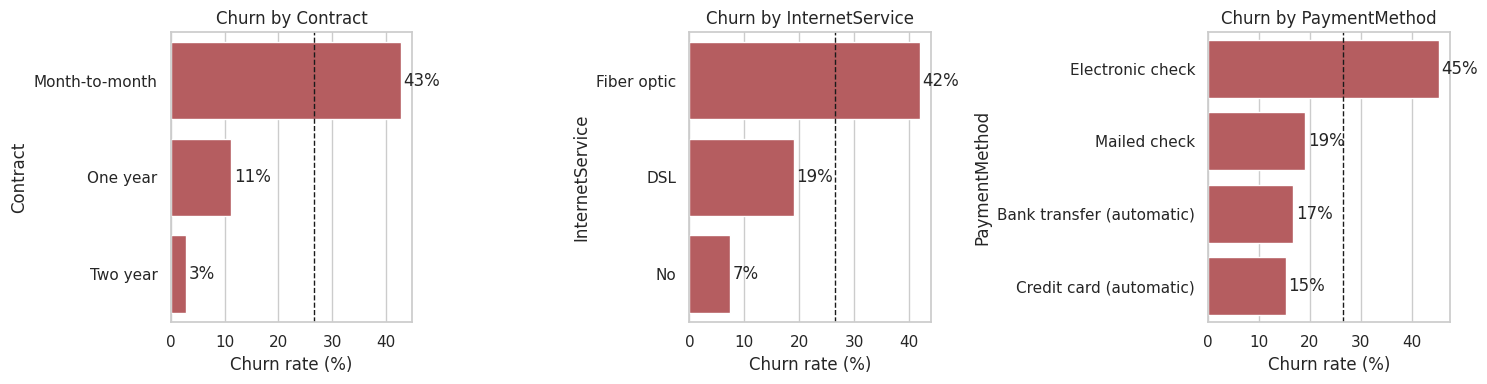

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Contract", "InternetService", "PaymentMethod"]):
    rate = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    sns.barplot(x=rate.values * 100, y=rate.index, ax=ax, color="#C44E52")
    ax.axvline(churn_rate * 100, color="k", ls="--", lw=1)
    ax.set_xlabel("Churn rate (%)"); ax.set_title(f"Churn by {col}")
    for i, v in enumerate(rate.values): ax.text(v * 100 + .5, i, f"{v:.0%}", va="center")
plt.tight_layout(); plt.savefig(FIG_DIR / "churn_by_category.png", dpi=150); plt.show()

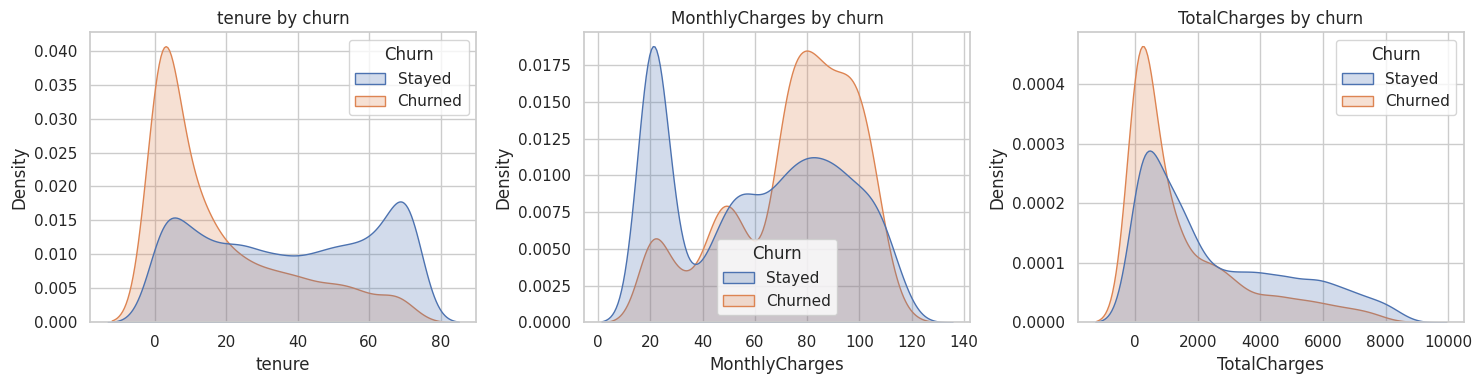

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.kdeplot(data=df, x=col, hue=df[TARGET].map({0: "Stayed", 1: "Churned"}), fill=True, common_norm=False, ax=ax)
    ax.set_title(f"{col} by churn")
plt.tight_layout(); plt.savefig(FIG_DIR / "numeric_distributions.png", dpi=150); plt.show()

Churners are concentrated at **low tenure** and **higher monthly charges**. Loyal long-tenure customers rarely leave.

        churn_rate  count
tenure                   
0-12m        0.474   2186
13-24m       0.287   1024
25-48m       0.204   1594
49-72m       0.095   2239


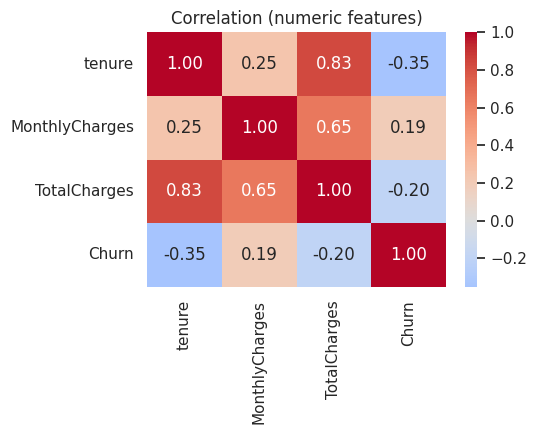

In [8]:
tg = pd.cut(df["tenure"], [-1, 12, 24, 48, 72], labels=["0-12m", "13-24m", "25-48m", "49-72m"])
print((df.groupby(tg)[TARGET].agg(["mean", "count"]).rename(columns={"mean": "churn_rate"})).round(3))

num = df[["tenure", "MonthlyCharges", "TotalCharges", TARGET]]
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation (numeric features)"); plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_heatmap.png", dpi=150); plt.show()

In [9]:
# Outlier check with the IQR rule
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    q1, q3 = df[col].quantile([.25, .75]); iqr = q3 - q1
    n = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f"{col:15s} outliers: {n}")

tenure          outliers: 0


MonthlyCharges  outliers: 0
TotalCharges    outliers: 0


No numeric outliers by the IQR rule, so no rows need to be removed or capped.

## 3. Statistical tests

Is each relationship real or just noise? Chi-square for categorical features, Mann-Whitney U for numeric ones (the distributions are not normal).

In [10]:
cat_cols = df.select_dtypes("object").columns.drop(ID_COL)
rows = []
for c in cat_cols:
    chi2, p, dof, _ = stats.chi2_contingency(pd.crosstab(df[c], df[TARGET]))
    n = len(df); cramers_v = np.sqrt(chi2 / (n * (min(pd.crosstab(df[c], df[TARGET]).shape) - 1)))
    rows.append((c, chi2, p, cramers_v))
chi_tbl = pd.DataFrame(rows, columns=["feature", "chi2", "p_value", "cramers_v"]).sort_values("cramers_v", ascending=False)
chi_tbl["significant (p<0.05)"] = chi_tbl["p_value"] < 0.05
chi_tbl.round(4).reset_index(drop=True)

,feature,chi2,p_value,cramers_v,significant (p<0.05)
0,Contract,1184.5966,0.0000,0.4101,True
1,OnlineSecurity,849.9990,0.0000,0.3474,True
2,TechSupport,828.1971,0.0000,0.3429,True
3,InternetService,732.3096,0.0000,0.3225,True
4,PaymentMethod,648.1423,0.0000,0.3034,True
5,OnlineBackup,601.8128,0.0000,0.2923,True
6,DeviceProtection,558.4194,0.0000,0.2816,True
7,StreamingMovies,375.6615,0.0000,0.2310,True
8,StreamingTV,374.2039,0.0000,0.2305,True
9,PaperlessBilling,258.2776,0.0000,0.1915,True


In [11]:
rows = []
for c in ["tenure", "MonthlyCharges", "TotalCharges"]:
    a, b = df.loc[df[TARGET] == 1, c], df.loc[df[TARGET] == 0, c]
    u, p = stats.mannwhitneyu(a, b)
    rows.append((c, a.median(), b.median(), p))
pd.DataFrame(rows, columns=["feature", "median_churned", "median_stayed", "p_value"]).round(4)

,feature,median_churned,median_stayed,p_value
0,tenure,10.00,38.000,0.0
1,MonthlyCharges,79.65,64.425,0.0
2,TotalCharges,703.55,1679.525,0.0


**Takeaways**
* `Contract`, `OnlineSecurity`, `TechSupport`, `InternetService` and `PaymentMethod` show the strongest associations with churn.
* `gender` and `PhoneService` are not significant, so they carry little signal.
* Churned customers have a much lower median tenure and higher median monthly charge.

## 4. Feature engineering and modelling

Engineered features (in `src/features.py`):
`tenure_group`, `num_services`, `avg_monthly_spend`, `has_security_support`.

They are computed inside a scikit-learn `Pipeline`, so there is **no data leakage** (scaling and encoding are fit on training folds only) and the same transformation is applied at prediction time.

In [12]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from src.features import split_xy
from src.train import make_pipeline, candidate_models
from src.config import TEST_SIZE, CV_FOLDS

X, y = split_xy(df)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_tr.shape, " Test:", X_te.shape, " Churn rate train/test:", round(y_tr.mean(), 3), round(y_te.mean(), 3))

Train: (5634, 19)  Test: (1409, 19)  Churn rate train/test: 0.265 0.265


In [13]:
cv = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
rows, fitted = [], {}
for name, est in candidate_models().items():
    pipe = make_pipeline(est)
    r = cross_validate(pipe, X_tr, y_tr, cv=cv, scoring=["roc_auc", "f1", "recall", "precision"])
    pipe.fit(X_tr, y_tr); fitted[name] = pipe
    rows.append({"model": name, "cv_auc": r["test_roc_auc"].mean(), "cv_auc_std": r["test_roc_auc"].std(),
                 "cv_recall": r["test_recall"].mean(), "cv_precision": r["test_precision"].mean(), "cv_f1": r["test_f1"].mean()})
cv_table = pd.DataFrame(rows).set_index("model").round(3)
cv_table

,cv_auc,cv_auc_std,cv_recall,cv_precision,cv_f1
model,,,,,
Logistic Regression,0.846,0.012,0.793,0.516,0.625
Random Forest,0.846,0.010,0.722,0.559,0.630
Gradient Boosting,0.846,0.010,0.783,0.528,0.630


All three models land at roughly the same ROC-AUC (about 0.85). That suggests the signal in this dataset is mostly linear and simple, so the **interpretable Logistic Regression is nearly as good as the ensembles**. Because they tie, I pick the **simplest model (Logistic Regression)**: it is easier to explain to a business team and cheaper to maintain. The same tie-break rule is used in `src/train.py`.

## 5. Evaluation on the hold-out test set

In [14]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve
# tie-break on rounded CV AUC: prefer the simpler model (same rule as src/train.py)
order = list(cv_table.index)
best_name = max(order, key=lambda n: (round(cv_table.loc[n, "cv_auc"], 3), -order.index(n))); best = fitted[best_name]
print("Selected model:", best_name)
proba = best.predict_proba(X_te)[:, 1]
print(classification_report(y_te, (proba >= .5).astype(int), target_names=["Stayed", "Churned"]))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_te, (proba >= .5).astype(int), display_labels=["Stayed", "Churned"], cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion matrix (threshold 0.5)")
for n, p in fitted.items(): RocCurveDisplay.from_estimator(p, X_te, y_te, name=n, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", alpha=.4); axes[1].set_title("ROC curves")
plt.tight_layout(); plt.show()

Selected model: Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1035
     Churned       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



### Choosing a decision threshold from business cost

A missed churner (false negative) costs more than a wasted retention offer (false positive). Instead of defaulting to 0.5, I compare thresholds. The costs below are **assumptions** for illustration: losing a customer = 500, a retention offer = 50. A 10:1 ratio pushes the optimum to a low threshold (high recall, low precision); a real team should plug in its own numbers.

In [15]:
COST_FN, COST_FP = 500, 50
ths = np.arange(0.1, 0.9, 0.05); costs = []
for t in ths:
    pred = (proba >= t).astype(int)
    fn = ((pred == 0) & (y_te == 1)).sum(); fp = ((pred == 1) & (y_te == 0)).sum()
    costs.append(fn * COST_FN + fp * COST_FP)
best_t = ths[int(np.argmin(costs))]
plt.figure(figsize=(6, 3.8)); plt.plot(ths, costs, marker="o"); plt.axvline(best_t, color="r", ls="--")
plt.xlabel("Decision threshold"); plt.ylabel("Total cost (assumed)"); plt.title(f"Lowest cost at threshold = {best_t:.2f}")
plt.tight_layout(); plt.savefig(FIG_DIR / "threshold_cost.png", dpi=150); plt.show()
pred = (proba >= best_t).astype(int)
print(f"At threshold {best_t:.2f}: recall={((pred==1)&(y_te==1)).sum()/(y_te==1).sum():.2f}, "
      f"precision={((pred==1)&(y_te==1)).sum()/max(pred.sum(),1):.2f}")

At threshold 0.20: recall=0.96, precision=0.39


## 6. Interpretation

In [16]:
from sklearn.inspection import permutation_importance
res = permutation_importance(best, X_te, y_te, scoring="roc_auc", n_repeats=10, random_state=RANDOM_STATE)
imp = pd.Series(res.importances_mean, index=X_te.columns).sort_values()
plt.figure(figsize=(6.5, 6)); imp.tail(12).plot.barh(color="#4C72B0")
plt.xlabel("Drop in ROC-AUC when shuffled"); plt.title("Permutation importance (original features)")
plt.tight_layout(); plt.savefig(FIG_DIR / "permutation_importance.png", dpi=150); plt.show()

In [17]:
import shap
plt.close("all")
fe, prep, model = best.named_steps["fe"], best.named_steps["prep"], best.named_steps["model"]
Xt = prep.transform(fe.transform(X_te)); names = prep.get_feature_names_out()
Xt = Xt.toarray() if hasattr(Xt, "toarray") else Xt
bg = shap.sample(Xt, 100, random_state=RANDOM_STATE)
explainer = shap.Explainer(lambda d: model.predict_proba(d)[:, 1], bg, feature_names=names)
sv = explainer(Xt[:300])
plt.figure()
shap.summary_plot(sv.values, Xt[:300], feature_names=names, show=False, max_display=12)
plt.tight_layout(); plt.savefig(FIG_DIR / "shap_summary.png", dpi=150, bbox_inches="tight"); plt.show()

**Reading the SHAP plot:** `Contract_Month-to-month`, `InternetService_Fiber optic`, a larger number of services and low `tenure` push the churn probability **up**. Two-year contracts, DSL, long tenure and having security/tech support push it **down**.

**Careful with `MonthlyCharges`:** on its own, churners pay more (section 2). Inside the model, a high monthly charge looks *protective*. This is because `MonthlyCharges` is strongly correlated with fiber optic, number of services and tenure, so once those are in the model, the leftover effect of price flips sign. This is a classic multicollinearity effect, so I would not conclude that raising prices reduces churn.

## 7. Business recommendations

In [18]:
c = df.groupby("Contract")[TARGET].mean()
s = df.groupby("TechSupport")[TARGET].mean()
f = df.groupby("InternetService")[TARGET].mean()
e = df.groupby("PaymentMethod")[TARGET].mean()
print(f"Month-to-month churn {c['Month-to-month']:.0%} vs two-year {c['Two year']:.0%}")
print(f"No tech support churn {s['No']:.0%} vs with support {s['Yes']:.0%}")
print(f"Fiber optic churn {f['Fiber optic']:.0%} vs DSL {f['DSL']:.0%}")
print(f"Electronic check churn {e['Electronic check']:.0%} vs others {df[df.PaymentMethod!='Electronic check'][TARGET].mean():.0%}")

Month-to-month churn 43% vs two-year 3%
No tech support churn 42% vs with support 15%
Fiber optic churn 42% vs DSL 19%
Electronic check churn 45% vs others 17%


1. **Move month-to-month customers to longer contracts** with a discount or perk, especially in their first 12 months.
2. **Bundle Tech Support and Online Security** free for the first months; customers without them churn far more.
3. **Investigate fiber-optic service quality and pricing**; it has the highest churn despite being the premium product.
4. **Push automatic payments** to customers paying by electronic check.
5. **Run a proactive retention campaign** on customers the model scores as High risk (see `src/predict.py`).

*Limitations:* the dataset is a snapshot with no time dimension, so the model shows association, not causation; cost figures are assumptions; and results should be re-validated on the company's own data before deployment.